In [38]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.get_intercepts_near_line import get_intercepts_near_line
from utility.my_colors import palette_light

from sparcl.client import SparclClient
from astropy.convolution import convolve, Gaussian1DKernel
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from scipy.integrate import trapezoid
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines, fit_generic_continuum
from specutils.analysis import fwhm, equivalent_width
from lmfit.models import Model, LinearModel, PolynomialModel, GaussianModel, PowerLawModel

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams.update({"legend.frameon":False})

hamann_erq_path = "data/core-ERQ-stats-coords.csv"
hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

### Data preparation

#### Load dataframes

In [39]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"DESI_targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq

,sdss_name,Plate,MJD,FiberID,ThingID,z_dr12,i,i_err,W3,W3_snr,...,kt75,kt80,rew_di,rewe_di,fwhm_di,qflag,rew_nv,frat_nv_civ,nvflag,DESI_targetid
0,000610.67+121501.2,5649,55912,288,220079389,2.309943,22.101451,0.160805,14.087,35.1,...,0.455485,0.372288,102.007661,6.075000,4508.508813,0,192.343862,1.880187,0,39628078766358575
1,000746.19+122223.9,6176,56264,194,221814072,2.429000,21.314343,0.079014,16.369,7.0,...,0.383122,0.284162,213.628344,4.754235,2550.825969,0,64.601598,0.388502,0,39628078770555722
2,002400.25+245031.9,6279,56243,28,328146826,2.809255,21.556824,0.090767,15.522,14.6,...,0.455389,0.372201,134.821509,10.120908,3694.810492,0,205.776721,2.455813,0,39628365275075274
3,004713.21+264024.7,6286,56301,800,342571394,2.563943,20.435463,0.038392,15.714,13.2,...,0.413071,0.325082,100.642397,5.476974,3662.920844,0,141.614347,1.923201,0,Not found
4,005044.95-021217.6,4370,55534,980,60738765,2.254000,21.473060,0.078552,16.760,4.6,...,0.262998,0.193256,148.782256,6.993491,5445.426756,0,46.553849,0.609687,0,39627730584601174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,5058,56208,124,172688138,2.608809,21.960453,0.106963,16.169,3.9,...,0.440905,0.356129,136.337135,3.430820,1318.560329,0,109.072962,1.034336,0,39627953214063409
93,225438.30+232714.5,6588,56536,390,315135318,3.087494,22.010175,0.120658,16.552,5.3,...,0.442837,0.358143,354.839828,22.560964,4906.586551,0,211.097222,0.660819,0,Not found
94,232326.17-010033.1,4210,55444,93,75229201,2.356070,22.410147,0.200206,15.218,19.1,...,0.454002,0.370693,260.264938,4.465699,4186.298391,0,565.970265,2.160131,0,39627766454292268
95,232828.47+044346.8,4283,55864,592,153323514,2.563872,21.532625,0.144071,16.066,9.3,...,0.437510,0.352179,356.552346,4.328203,1575.355245,0,122.280344,0.373535,0,39627905315113841


#### Retrieve spectra

In [40]:
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [ ]:
idxs = [int(x) for x in hamann_erq["DESI_targetid"].head(3) if x != "Not found"]

output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

In [42]:
spectra_df = pd.DataFrame(spectra.data[1:])
spectra_df

,specprimary,data_release,redshift,spectype,redshift_warning,targetid,specid,desi_target,survey,flux,wavelength,_dr
0,True,DESI-DR1,2.199301,QSO,0,39628078766358575,39628078766358575,262148,main,"[6.083261489868164, 7.300170421600342, 5.58030...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,True,DESI-DR1,2.837482,QSO,0,39628365275075274,39628365275075274,4611686018428305446,main,"[0.7628244161605835, -1.0635453462600708, 0.83...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,True,DESI-DR1,2.430429,QSO,0,39628078770555722,39628078770555722,4611686018428305446,main,"[1.2459850311279297, -3.726759195327759, -1.50...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


### Line measurements

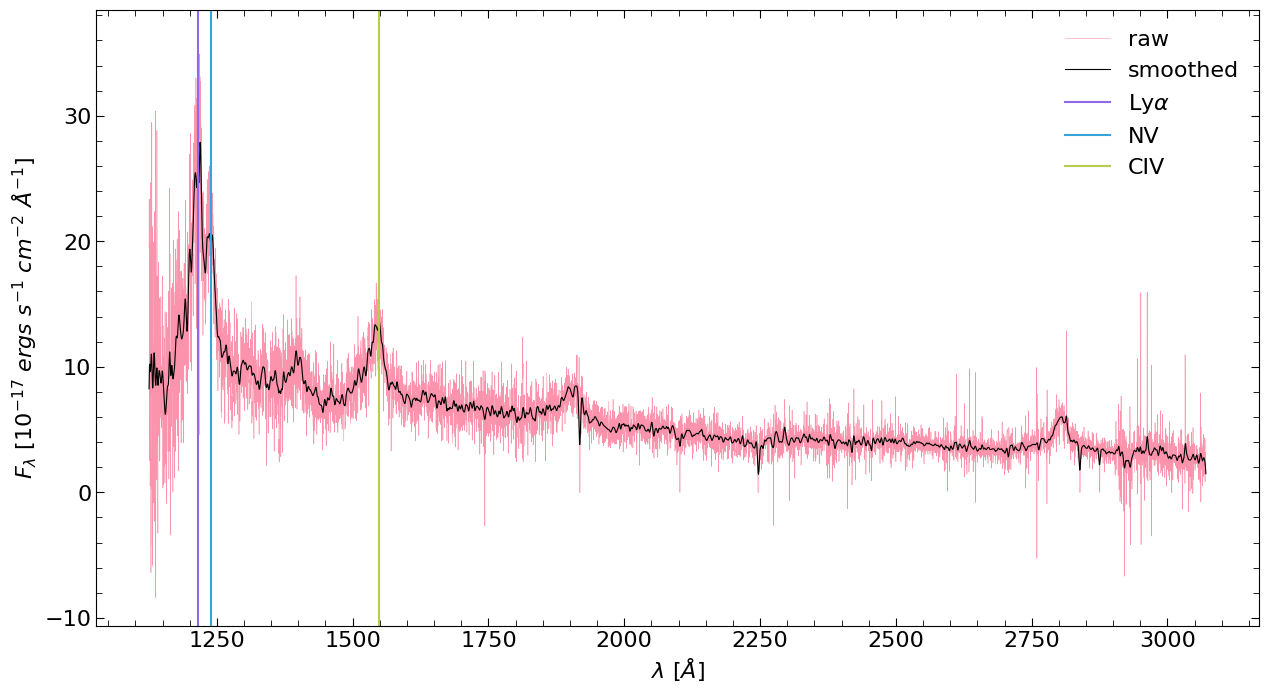

In [43]:
idx = 0

lam = np.array(spectra_df["wavelength"][idx])
flux = np.array(spectra_df["flux"][idx])
z = spectra_df["redshift"][idx]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux, line_lambda=[1215,1240,1549], line_label=[r"Ly$\alpha$","NV","CIV"])

#### continuum fit w/ specutils

In [44]:
## create Spectrum1D object

flux_unit = u.erg / (u.s * u.cm**2 * u.AA)  # define unit

# components must be "Quantity" objects (hence _q suffixes), which has units
flux_q = flux * flux_unit # convolve(flux, Gaussian1DKernel(5)) * flux_unit
lam_q = lam * u.AA

spec1d = Spectrum1D(flux=flux_q, spectral_axis=lam_q)

In [45]:
nv_lya_region = SpectralRegion(1150*u.AA, 1250*u.AA)
civ_region = SpectralRegion(1500*u.AA, 1600*u.AA)

continuum_fit = fit_generic_continuum(spec1d, exclude_regions=[nv_lya_region, civ_region])

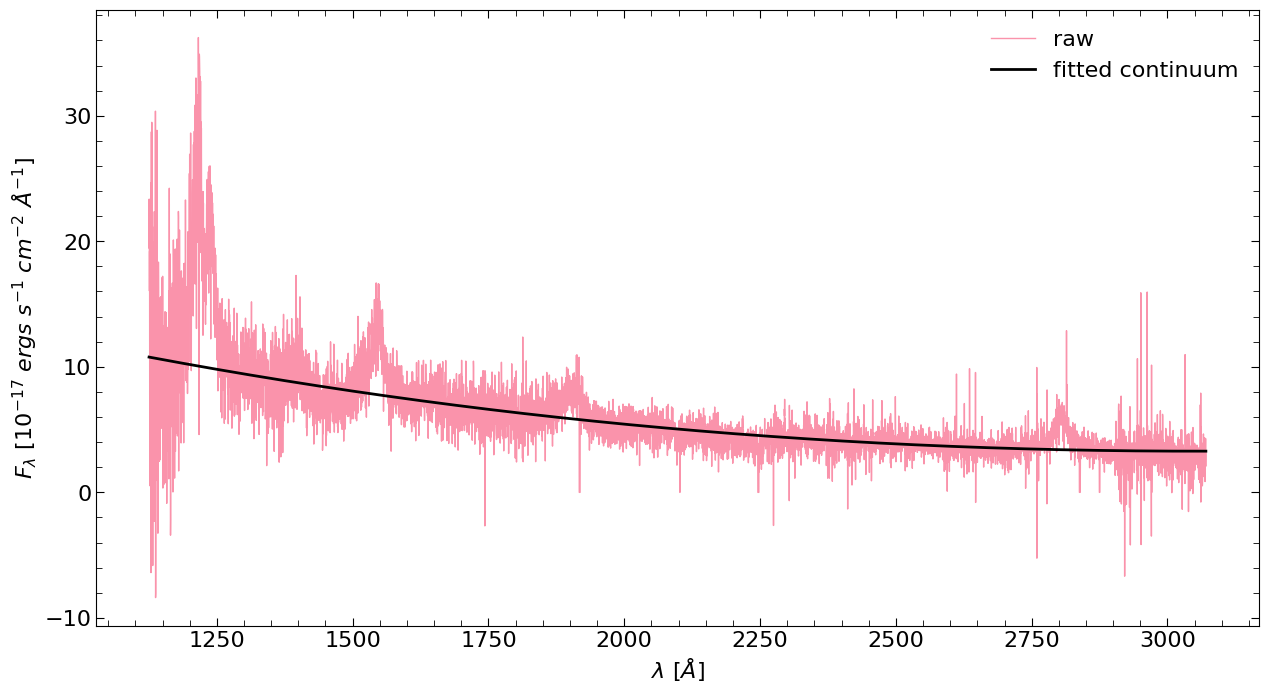

In [54]:
y_continuum_fitted = continuum_fit(lam_q)

plot_spectrum(lam_q, flux_q, additional_flux=y_continuum_fitted, additional_flux_label="fitted continuum", line_width_factor=2.5,add_smoothed=False,title="",flux_label="raw")

#### line fits w/ lmfit

In [47]:
lower_lim, upper_lim = 1400,1750  # establish limits

subset_mask = (lam > lower_lim) & (lam < upper_lim )

lam_subset = lam[subset_mask]
flux_subset = flux[subset_mask]
continuum_subset = y_continuum_fitted[subset_mask]  # get only relevant subset from continuum

# flux_subset = convolve(flux_subset, Gaussian1DKernel(5))
flux_subset = np.array(flux_subset)

lam_subset = np.array(lam_subset)

In [48]:
gaussian1 = GaussianModel(prefix="g1_")
gaussian2 = GaussianModel(prefix="g2_")
background = LinearModel()
model = gaussian1 + gaussian2 + background

# check which params need to be specified
print('parameter names: {}'.format(model.param_names))
print('independent variables: {}'.format(model.independent_vars))

parameter names: ['g1_amplitude', 'g1_center', 'g1_sigma', 'g2_amplitude', 'g2_center', 'g2_sigma', 'slope', 'intercept']
independent variables: ['x']


In [49]:
params = model.make_params()

amplitude = max(flux_subset)
intercepts = get_intercepts_near_line(lam_subset, flux_subset, continuum_subset.value)
sigma = (intercepts[1]-intercepts[0])/4


params['g1_center'].set(value=1550)
params['g1_amplitude'].set(value=amplitude)
params['g1_sigma'].set(value=sigma/2)

params['g2_center'].set(value=1548)
params['g2_amplitude'].set(value=amplitude/2)
params['g2_sigma'].set(value=sigma)

params["slope"].set(value=0)
params["intercept"].set(value=1)
# params["amplitude"].set(value=1)
# params["exponent"].set(value=0.5)

result = model.fit(flux_subset, params, x=lam_subset)


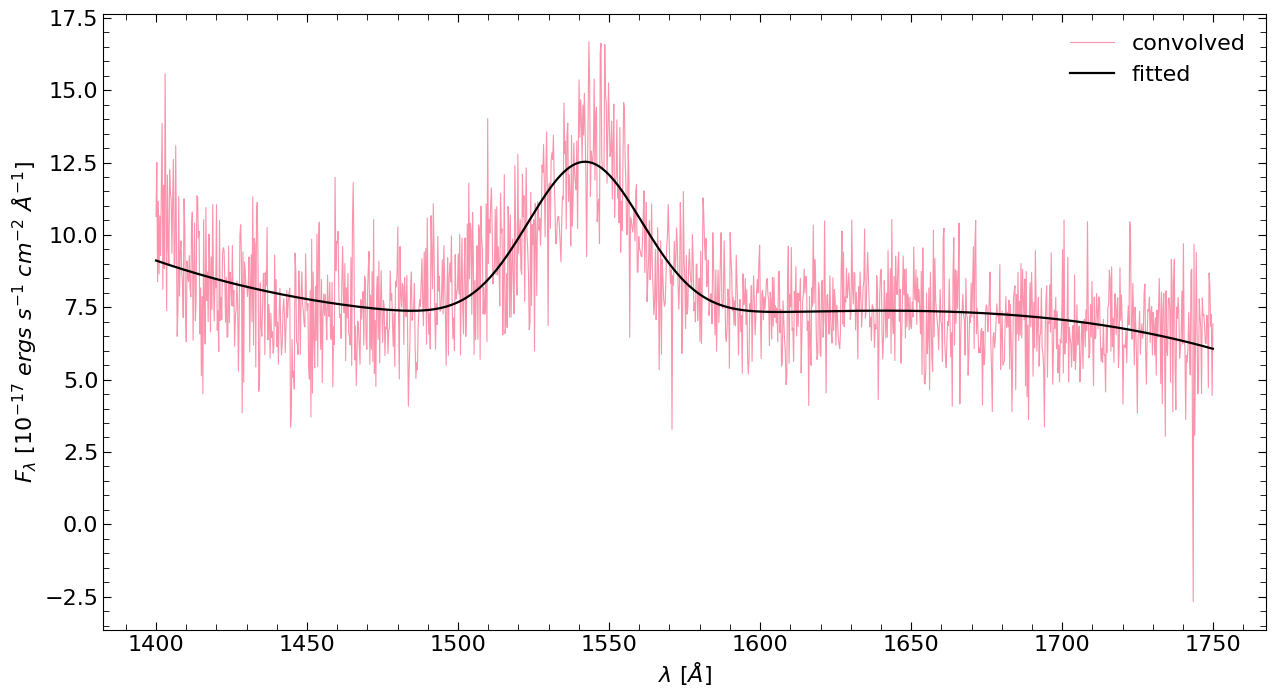

In [55]:
y_fit = result.best_fit  # extract y values from fit

components = result.eval_components(x=lam_subset)
linear_comp = components["linear"]

# comparison of fitted spectrum with original one
plot_spectrum(lam_subset, flux_subset, title="", flux_label="convolved", add_smoothed=False, additional_flux=y_fit, additional_flux_label="fitted", line_width_factor=2)        

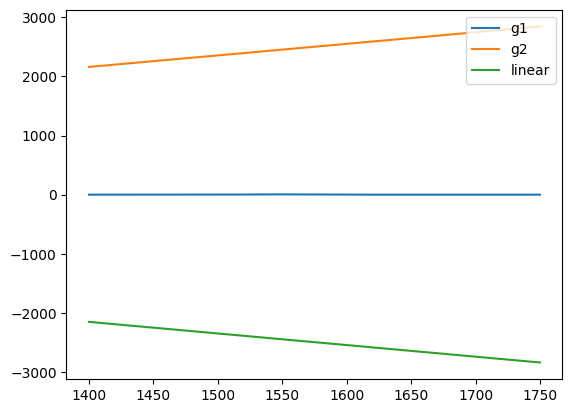

In [51]:
plt.plot(lam_subset,components["g1_"],label="g1")
plt.plot(lam_subset,components["g2_"],label="g2")
plt.plot(lam_subset,components["linear"],label="linear")
plt.legend()
plt.show()

In [52]:
gaussian_spec = Spectrum1D(spectral_axis=lam_subset*u.AA,flux=(y_fit-continuum_subset.value)*flux_unit)

equivalent_width(gaussian_spec)
# (fwhm(gaussian_spec)/1549)*2.998e5

<Quantity 189.80506701 Angstrom>

In [57]:
# intercepts = get_intercepts_near_line(lam_subset, y_fit, linear_comp)

# flux_mask = (lam_subset > intercepts[0]) & (lam_subset < intercepts[1])

# plt.plot(lam_subset,continuum,label="continuum fit",color=palette_light[0])
# plt.plot(lam_subset,y_fit,label="line fit",color=palette_light[1])

# plt.plot(lam_subset[flux_mask],y_fit[flux_mask], color=palette_light[2], label="subset to integrate")

# plt.legend(frameon=False)

# plt.show()

In [59]:
# trapezoid(y_fit[flux_mask],lam_subset[flux_mask])